# Credit Card Customer Segmentation

## Executive Summary
This project segments 8,950 credit card customers using behavioral data to inform
marketing and risk strategy. Three clustering algorithms (K-Means, Hierarchical, DBSCAN)
were applied and cross-validated.

**Key Findings**
- Customer behavior follows a **continuous spectrum**, not discrete groups
- The primary axis of variance separates **Purchase-Focused** from **Cash-Reliant** customers
- K-Means K=2 with 90.7% cross-algorithm agreement provides the most actionable segmentation
- DBSCAN identified 309 customers (3.5%) requiring individual attention

**Approach**
Data cleaning → Feature engineering → Skew reduction → Scaling → PCA (8 components)
→ Clustering (3 methods) → Cross-validation → Profile analysis

**Outcome**
A robust 2-segment framework supplemented by outlier detection,
ready for marketing strategy design with domain expert validation.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/arjunbhasin2013/ccdata/CC GENERAL.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/arjunbhasin2013/ccdata/CC GENERAL.csv')
df.sample()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
1231,C11275,1134.726574,1.0,0.0,0.0,0.0,19.555003,0.0,0.0,0.0,0.083333,1,0,1200.0,78.603131,7639.575747,0.0,12


In [3]:
df.drop('CUST_ID', axis=1, inplace=True)
df.isnull().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [4]:
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

## Feature Engineering

New features were created to better capture customer financial behavior beyond raw transaction data.

**Utilization** (`BALANCE / CREDIT_LIMIT`)
Measures how much of the credit limit a customer is actively using.
High utilization signals financial stress or heavy reliance on credit.

**Payment Ratio** (`PAYMENTS / MINIMUM_PAYMENTS`)
Indicates how responsibly a customer repays their debt.
A ratio close to 1 means paying only the minimum — higher values suggest healthier repayment behavior.

**Cash Advance Dependency** (`CASH_ADVANCE / (PURCHASES + CASH_ADVANCE)`)
Captures how much a customer relies on cash withdrawals versus normal purchases.
High dependency is a strong signal of financial distress — cash advances carry high fees and interest.

**Installment Ratio** (`INSTALLMENTS_PURCHASES / PURCHASES`)
Shows what proportion of spending is done through installment plans.
A high ratio suggests a preference for structured, planned purchases over impulsive spending.

In [5]:
def feature_engineering(dataframe: pd.DataFrame) -> pd.DataFrame:
    dataframe = dataframe.copy()
    dataframe['utilization']       = dataframe['BALANCE'] / dataframe['CREDIT_LIMIT']
    dataframe['payment_ratio']     = dataframe['PAYMENTS'] / dataframe['MINIMUM_PAYMENTS']
    dataframe['CA_dependency']     = dataframe['CASH_ADVANCE'] / (dataframe['PURCHASES'] + dataframe['CASH_ADVANCE'])
    dataframe['installment_ratio'] = dataframe['INSTALLMENTS_PURCHASES'] / dataframe['PURCHASES']
    
    # Replace inf: occurs when dividing a non-zero value by 0 (e.g. PAYMENTS / 0)
    dataframe = dataframe.replace([float('inf'), float('-inf')], 0)
    
    # Replace NaN: occurs when dividing 0 by 0 (e.g. installment_ratio when both
    # INSTALLMENTS_PURCHASES and PURCHASES are 0 — customer made no purchases at all)
    dataframe = dataframe.fillna(0)
    
    return dataframe
df = feature_engineering(df)

In [6]:
df.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
utilization                         0
payment_ratio                       0
CA_dependency                       0
installment_ratio                   0
dtype: int64

## Ghost Card Detection

**What is a Ghost Card?**
A ghost card is a credit card account that exists but is barely used.
Identified by zero purchases, zero cash advances, and near-zero purchase frequency.
These customers hold an active account but generate almost no transaction activity.

**Why It Matters for Segmentation**
Ghost cards represent a distinct behavioral segment that standard clustering may overlook.
Without flagging them explicitly, they risk being merged into other segments and distorting cluster profiles.
From a business perspective, ghost card holders are high churn risk — the card offers them no perceived value.

In [7]:
def ghost_card_feature(dataframe: pd.DataFrame) -> None:
    threshold = dataframe['PURCHASES_FREQUENCY'].quantile(0.25)
    
    ghost_card_mask = (
        (dataframe['PURCHASES'] == 0) &
        (dataframe['CASH_ADVANCE'] == 0) 
        # (df['PURCHASES_FREQUENCY'] <= threshold)
    )

    
    print(f"Ghost Cards: {ghost_card_mask.sum()} ({ghost_card_mask.mean()*100:.1f}%)")
    
ghost_card_feature(df)

Ghost Cards: 1 (0.0%)


## Ghost Card Detection

**Result: Feature Dropped**
Only 1 ghost card was found in this dataset (0.01% of 8,950 customers).
Adding a feature with near-zero variance adds noise without meaningful signal for clustering.

**When to Use This Feature**
Ghost card detection is still a valuable technique for other datasets.
If ghost cards represent a meaningful proportion of customers (e.g. 5%+),
it becomes a strong behavioral signal worth including in segmentation.

In [8]:
zero_inflation = (df == 0).mean() * 100
print("Zero Inflation (% of zeros):")
print(zero_inflation.sort_values(ascending=False).round(2))

Zero Inflation (% of zeros):
PRC_FULL_PAYMENT                    65.96
CASH_ADVANCE_FREQUENCY              51.71
CASH_ADVANCE_TRX                    51.71
CASH_ADVANCE                        51.71
CA_dependency                       51.71
ONEOFF_PURCHASES                    48.07
ONEOFF_PURCHASES_FREQUENCY          48.07
installment_ratio                   43.78
INSTALLMENTS_PURCHASES              43.75
PURCHASES_INSTALLMENTS_FREQUENCY    43.74
PURCHASES_TRX                       22.84
PURCHASES                           22.84
PURCHASES_FREQUENCY                 22.83
payment_ratio                        2.68
PAYMENTS                             2.68
BALANCE_FREQUENCY                    0.89
BALANCE                              0.89
utilization                          0.89
CREDIT_LIMIT                         0.00
TENURE                               0.00
MINIMUM_PAYMENTS                     0.00
dtype: float64


## Zero-Inflation Analysis

**What is Zero-Inflation?**
Zero-inflation occurs when a feature contains an unusually high proportion of zeros.
In credit card data, zero is not missing data — it represents real customer behavior.
For example, `CASH_ADVANCE = 0` means the customer simply never withdrew cash, not that the data is absent.

**Why Fill NaN with 0 or Mode?**
For zero-inflated features, NaN most likely means the customer did not perform that action.
Since the majority behavior is non-usage (0), filling with 0 or mode preserves the true distribution
and avoids introducing artificial signal that could distort clustering results.

In [9]:
corr_matrix = df.select_dtypes(include='number').corr().abs()

#upper triangle
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

#correlation > 0.85
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]


print("Features ที่ correlate กันสูง (> 0.85):")
for col in upper.columns:
    high_corr = upper.index[upper[col] > 0.85].tolist()
    for row in high_corr:
        print(f"  {row} <-> {col} : {corr_matrix.loc[row, col]:.2f}")

print(f"\nDrop: {to_drop}")
df = df.drop(columns=to_drop)

Features ที่ correlate กันสูง (> 0.85):
  PURCHASES <-> ONEOFF_PURCHASES : 0.92
  PURCHASES_FREQUENCY <-> PURCHASES_INSTALLMENTS_FREQUENCY : 0.86

Drop: ['ONEOFF_PURCHASES', 'PURCHASES_INSTALLMENTS_FREQUENCY']


In [10]:
def reduce_skewness(dataframe: pd.DataFrame, threshold: float = 1.0) -> pd.DataFrame:
    """
    Reduce skewness for highly skewed features.
    
    Steps:
    1. Cap extreme outliers at 99th percentile (skew > 10)
    2. Apply log1p transform to features with skew > threshold
    """
    dataframe = dataframe.copy()
    # Step 1: Cap extreme outliers before log transform
    extreme_features = dataframe.skew()[dataframe.skew() > 10].index.tolist()
    for col in extreme_features:
        cap = dataframe[col].quantile(0.99)
        dataframe[col] = dataframe[col].clip(upper=cap)
    
    # Step 2: Log transform features with skew > threshold
    skewed_features = dataframe.skew()[dataframe.skew() > threshold].index.tolist()
    dataframe[skewed_features] = dataframe[skewed_features].apply(lambda x: np.log1p(x))
    
    print(f"Capped extreme outliers: {extreme_features}")
    print(f"Log transformed: {skewed_features}")
    
    return dataframe

df_skew = reduce_skewness(df)

Capped extreme outliers: ['MINIMUM_PAYMENTS', 'payment_ratio']
Log transformed: ['BALANCE', 'PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'ONEOFF_PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'utilization', 'payment_ratio']


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_skew)
df_scaled = pd.DataFrame(scaled_array, columns=df_skew.columns)

In [12]:
df_scaled.isnull().sum()

BALANCE                       0
BALANCE_FREQUENCY             0
PURCHASES                     0
INSTALLMENTS_PURCHASES        0
CASH_ADVANCE                  0
PURCHASES_FREQUENCY           0
ONEOFF_PURCHASES_FREQUENCY    0
CASH_ADVANCE_FREQUENCY        0
CASH_ADVANCE_TRX              0
PURCHASES_TRX                 0
CREDIT_LIMIT                  0
PAYMENTS                      0
MINIMUM_PAYMENTS              0
PRC_FULL_PAYMENT              0
TENURE                        0
utilization                   0
payment_ratio                 0
CA_dependency                 0
installment_ratio             0
dtype: int64

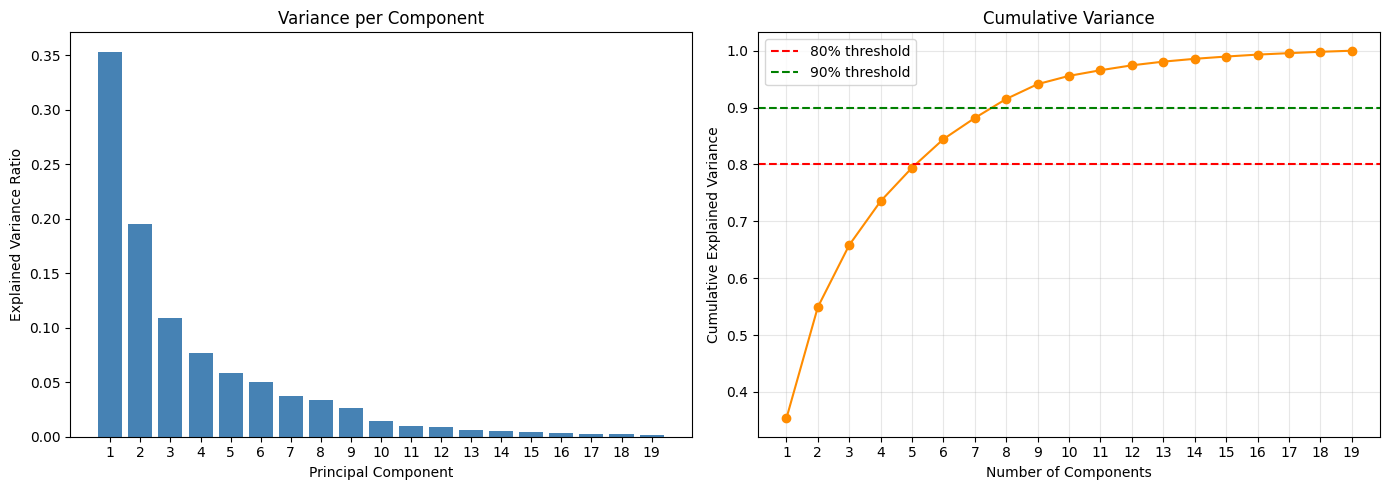

PC1: 35.35%  |  Cumulative: 35.35%
PC2: 19.56%  |  Cumulative: 54.91%
PC3: 10.91%  |  Cumulative: 65.82%
PC4: 7.72%  |  Cumulative: 73.54%
PC5: 5.89%  |  Cumulative: 79.43%
PC6: 5.03%  |  Cumulative: 84.46%
PC7: 3.72%  |  Cumulative: 88.17%
PC8: 3.35%  |  Cumulative: 91.52%
PC9: 2.60%  |  Cumulative: 94.12%
PC10: 1.45%  |  Cumulative: 95.58%
PC11: 0.99%  |  Cumulative: 96.57%
PC12: 0.86%  |  Cumulative: 97.43%
PC13: 0.65%  |  Cumulative: 98.08%
PC14: 0.50%  |  Cumulative: 98.58%
PC15: 0.40%  |  Cumulative: 98.97%
PC16: 0.34%  |  Cumulative: 99.32%
PC17: 0.26%  |  Cumulative: 99.57%
PC18: 0.24%  |  Cumulative: 99.81%
PC19: 0.19%  |  Cumulative: 100.00%


In [13]:
from sklearn.decomposition import PCA

# Fit PCA with all components first to see variance distribution
pca = PCA()
pca.fit(df_scaled)

# Calculate cumulative variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance per component
ax[0].bar(range(1, len(explained_variance) + 1), explained_variance, color='steelblue')
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('Explained Variance Ratio')
ax[0].set_title('Variance per Component')
ax[0].set_xticks(range(1, len(explained_variance) + 1))

# Cumulative variance
ax[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='darkorange')
ax[1].axhline(y=0.80, color='red', linestyle='--', label='80% threshold')
ax[1].axhline(y=0.90, color='green', linestyle='--', label='90% threshold')
ax[1].set_xlabel('Number of Components')
ax[1].set_ylabel('Cumulative Explained Variance')
ax[1].set_title('Cumulative Variance')
ax[1].set_xticks(range(1, len(cumulative_variance) + 1))
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print table
for i, (var, cum) in enumerate(zip(explained_variance, cumulative_variance), 1):
    print(f"PC{i}: {var*100:.2f}%  |  Cumulative: {cum*100:.2f}%")

## PCA — Dimensionality Reduction

**Observation**
Cumulative variance plot shows that 8 components retain ~91% of total variance,
crossing the 90% threshold while remaining well below the original 19 features.

**Key Insight**
Reducing to 8 components preserves nearly all behavioral signal while removing
noise from low-variance components. The elbow at PC 4–5 followed by gradual decline
suggests that components 6–8 still carry meaningful information worth retaining.

**Decision**
Use 8 components (~91% variance) — meets the 90% retention standard while
keeping dimensionality manageable for downstream clustering.

In [14]:
# Apply PCA with 5 components — retains ~93% of variance
pca = PCA(n_components=8)
df_pca = pca.fit_transform(df_scaled)

# Convert to DataFrame for easier handling downstream
df_pca = pd.DataFrame(
    df_pca,
    columns=[f'PC{i+1}' for i in range(8)]
)

# Verify variance retained
print(f"Total variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(df_pca.head())

Total variance retained: 91.52%
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -1.459301 -2.380294 -1.486513  0.366857  0.781497 -0.263273  0.534889   
1  3.585216  0.074752  1.547293 -0.097083  1.266431 -0.048827 -0.962426   
2 -1.079273  1.636863 -0.326586 -2.924861 -1.085914  0.719787 -0.140580   
3  0.958036 -1.971071 -1.690544 -1.480897 -0.930282  2.867973  0.070541   
4  0.583458 -1.234102 -0.898951 -1.962125  0.540097 -1.642094  0.044399   

        PC8  
0 -0.202663  
1  0.180446  
2  0.500374  
3  1.253367  
4 -0.400135  


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


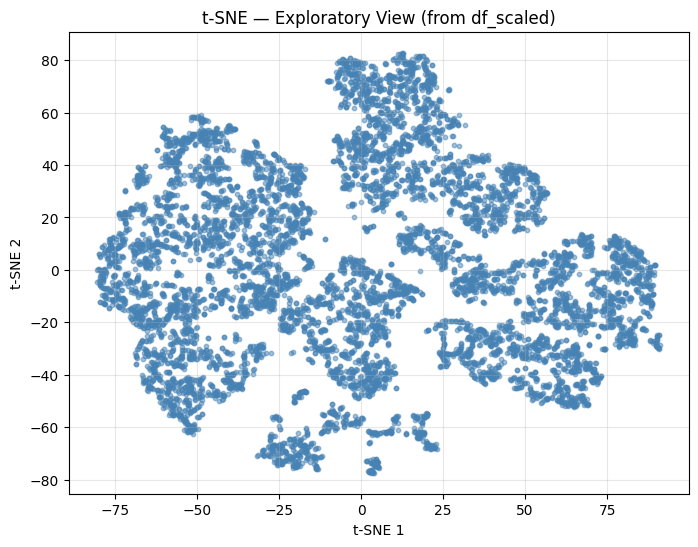

In [15]:
from sklearn.manifold import TSNE

# Apply t-SNE  
tsne = TSNE(
    n_components=2,      # Reduce to 2D for visualization
    perplexity=30,       # Balances local vs global structure (typical range: 5-50)
    random_state=42,     # For reproducibility
    n_iter=1000          # More iterations = more stable result
)

df_tsne = tsne.fit_transform(df_pca)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(df_tsne[:, 0], df_tsne[:, 1], alpha=0.5, s=10, color='steelblue')
plt.title('t-SNE — Exploratory View (from df_scaled)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(alpha=0.3)
plt.show()

## t-SNE — Exploratory Visualization

**Observation**
t-SNE projection shows a continuous structure with 4–5 loosely defined groups
and several small isolated clusters at the bottom. Boundaries between main groups
are soft, with notable overlap in the center.

**Key Insight**
The data has underlying structure but customer behavior appears to lie on a spectrum
rather than splitting into sharply distinct types. The initial estimate of cluster count
should be validated against the dendrogram and silhouette score before finalizing.


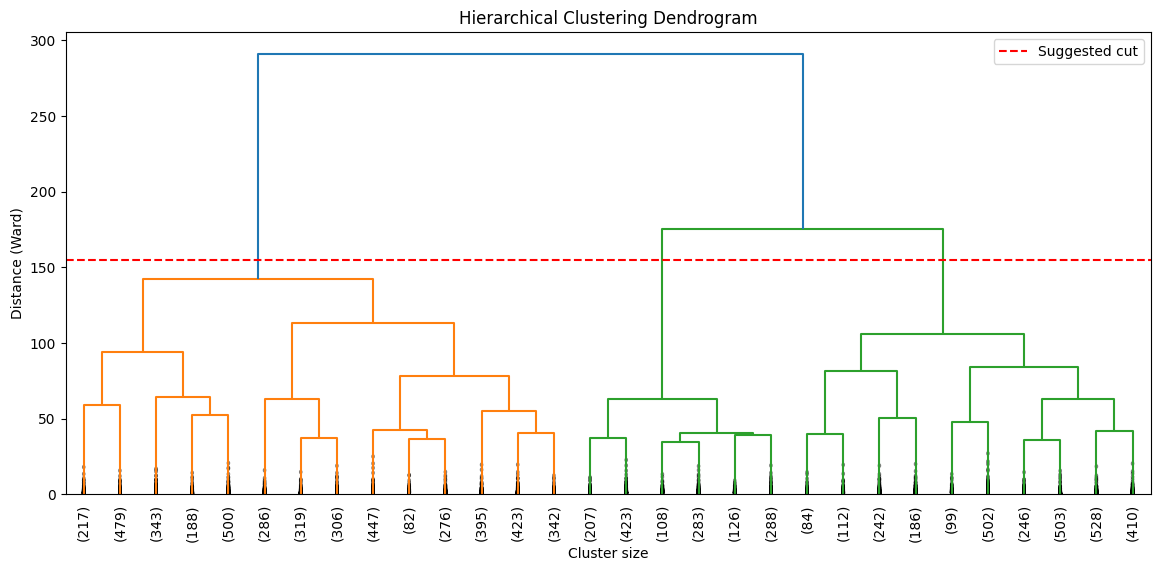

In [16]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster


# Step 1: Compute linkage matrix
# 'ward' minimizes variance within clusters — works well with Euclidean distance
linkage_matrix = linkage(df_pca, method='ward')

# Step 2: Plot dendrogram to visualize cluster structure
plt.figure(figsize=(14, 6))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',   # Show only last p merged clusters
    p=30,                    # Number of clusters to show at the bottom
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cluster size')
plt.ylabel('Distance (Ward)')
plt.axhline(y=155, color='red', linestyle='--', label='Suggested cut')  # ปรับตาม dendrogram
plt.legend()
plt.show()

## Hierarchical Clustering — Cluster Number Selection

**Observation**
The dendrogram shows the largest vertical gap at the top split (~290),
which statistically suggests 2 clusters as the cleanest separation.
Cutting at distance ≈ 155 yields 3 clusters — one from the orange branch
and two from the green branch.

**Key Insight**
While 2 clusters is the mathematical optimum, it offers limited business value —
splitting customers into just "high vs low value" prevents tailored marketing
and loses upsell/cross-sell opportunities.

3 clusters strikes a better balance:
- Highest Silhouette Score among tested K values (0.212), confirming the cleanest separation beyond K=2
- Provides actionable granularity without over-fragmenting the segments
- Aligns with the natural break just below the top-level split

**Decision**
Cut the dendrogram at distance ≈ 155 to extract 3 clusters.
This balances statistical structure (Silhouette winner) with business utility,
giving marketing teams meaningful segments that remain easy to operationalize.

In [17]:
n_clusters = 3  # ปรับตามที่เลือกจาก dendrogram

cluster_labels = fcluster(linkage_matrix, t=n_clusters, criterion='maxclust')

# Add to dataframe for analysis
df['hierarchy_cluster'] = cluster_labels

print(f"Cluster distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())

Cluster distribution:
1    4603
2    1435
3    2912
Name: count, dtype: int64


In [18]:
from sklearn.metrics import silhouette_score

for k in [3, 4, 5, 6]:
    labels = fcluster(linkage_matrix, t=k, criterion='maxclust')
    score = silhouette_score(df_pca, labels)
    print(f"K={k}: Silhouette = {score:.3f}")

K=3: Silhouette = 0.212
K=4: Silhouette = 0.189
K=5: Silhouette = 0.185
K=6: Silhouette = 0.194


## Silhouette Score — Validation of Cluster Count

**Observation**
K=3 produces the highest score, but all tested values fall below 0.25 —
indicating that the dataset does not contain strong natural cluster boundaries.

**Key Insight**
Low silhouette scores across all K values reveal that customer behavior lies on a
continuous spectrum rather than splitting into sharply distinct groups. This is common
in real-world credit card data — customers gradually shift between behavioral patterns
(e.g. Light → Medium → Heavy users) without clear-cut transitions.

The differences between K values are also small (range 0.027), meaning no K is
statistically dominant. In this situation, business context must guide the final choice
rather than relying on the metric alone.

**Decision**
Proceed with K=3 — the mathematical winner — while acknowledging that any chosen K
imposes structure on inherently continuous behavior. The clusters should be interpreted
as behavioral *tendencies*, not rigid categories.

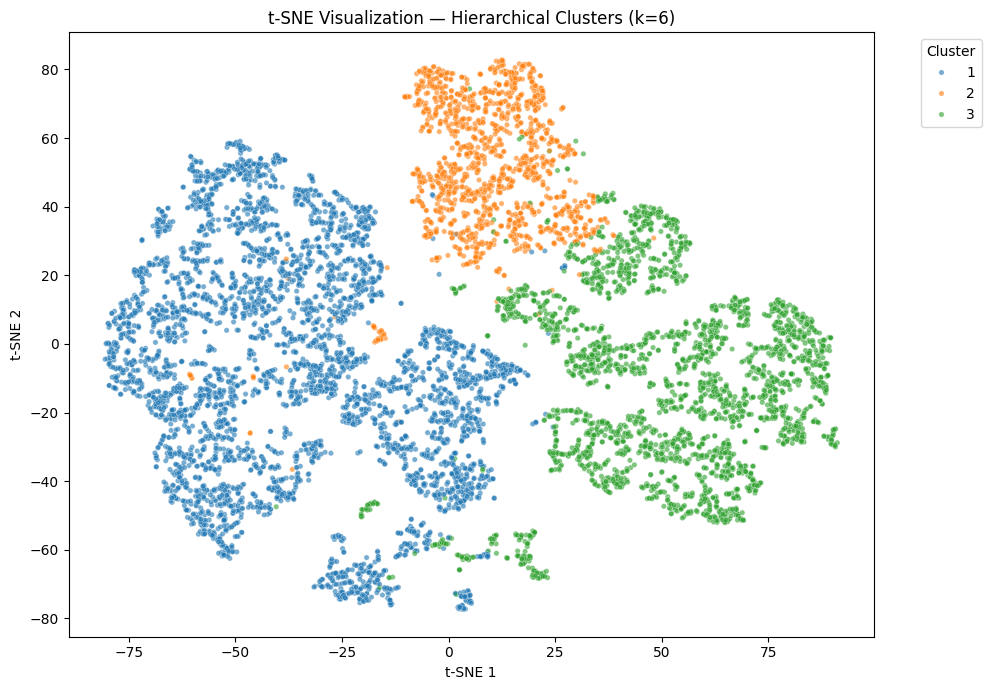


Cluster sizes:
1    4603
2    1435
3    2912
Name: count, dtype: int64


In [19]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=df_tsne[:, 0],
    y=df_tsne[:, 1],
    hue=cluster_labels,
    palette='tab10',
    alpha=0.6,
    s=15
)
plt.title('t-SNE Visualization — Hierarchical Clusters (k=6)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print cluster size distribution
print("\nCluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())

## t-SNE Cluster Visualization — Why It Doesn't Look "Perfect"

**Observation**
The 2D t-SNE plot shows 3 clusters with visible overlap and a few small isolated groups,
rather than clean, fully separated blobs.

**Key Insight**
The plot compresses ~18 dimensions of customer behavior into just 2 dimensions for
visualization. Boundaries that are clean in the full feature space can look messy in 2D
because t-SNE preserves local neighborhoods but distorts global distances.

In [20]:
df.groupby('hierarchy_cluster').mean().round(2).T

hierarchy_cluster,1,2,3
BALANCE,793.95,2846.90,2150.48
BALANCE_FREQUENCY,0.84,0.98,0.89
PURCHASES,1365.61,1582.07,145.09
INSTALLMENTS_PURCHASES,576.89,663.16,24.72
CASH_ADVANCE,4.08,2046.89,1993.42
PURCHASES_FREQUENCY,0.67,0.74,0.09
ONEOFF_PURCHASES_FREQUENCY,0.26,0.32,0.06
CASH_ADVANCE_FREQUENCY,0.00,0.28,0.28
CASH_ADVANCE_TRX,0.02,7.20,6.40
PURCHASES_TRX,19.61,25.52,1.64


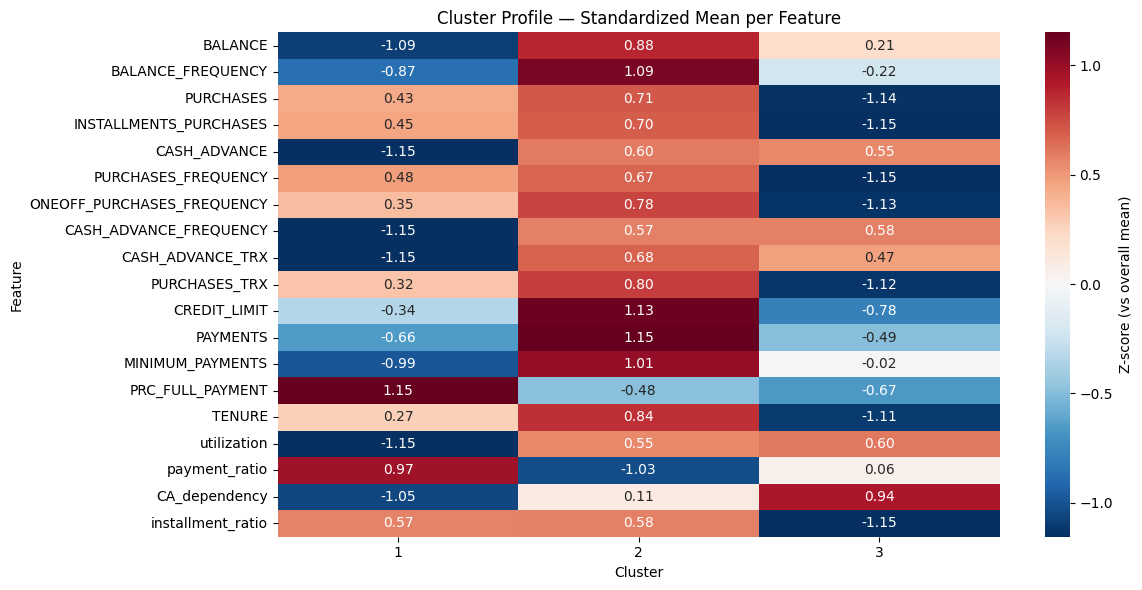

In [21]:
import seaborn as sns

# Normalize เพื่อให้เปรียบเทียบข้าม feature ได้
cluster_profile = df.groupby('hierarchy_cluster').mean()
cluster_normalized = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()

plt.figure(figsize=(12, 6))
sns.heatmap(
    cluster_normalized.T,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f',
    cbar_kws={'label': 'Z-score (vs overall mean)'}
)
plt.title('Cluster Profile — Standardized Mean per Feature')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Cluster Profile — Behavioral Segmentation

**Observation**
Heatmap shows z-scored mean of each feature per cluster (red = above average, blue = below average),
revealing 3 distinct behavioral segments across spending, payment, and cash advance dimensions.

**Key Insight — Cluster Personas**

**Cluster 1 — Disciplined Light Users**
High full-payment rate (+1.15) and payment ratio (+0.97), with very low cash advance,
balance, and utilization. Moderate purchase activity with installment preference.
Healthy customers who use the card responsibly — low risk, low revenue.

**Cluster 2 — High-Activity Revolvers**
High across nearly every dimension — purchases (+0.71), cash advance (+0.60),
credit limit (+1.13), payments (+1.15), and tenure (+0.84) — but low full payment (-0.48)
and very low payment ratio (-1.03). Bank's most valuable yet riskiest segment:
heavy spenders who carry balance and pay only the minimum.

**Cluster 3 — Cash-Reliant Newcomers**
Very low purchase activity across all measures, short tenure (-1.11), and low credit limit (-0.78).
High cash advance dependency (+0.94) and utilization (+0.60). Newer customers using the card
mainly for cash withdrawals — early signs of financial stress.


In [22]:
from sklearn.cluster import KMeans

# Range of K values to test
k_range = range(2, 11)

# Store metrics for each K
inertia_scores = []      # For Elbow Method (lower = tighter clusters)
silhouette_scores = []   # For Silhouette (higher = better separated)

# Loop through each K and fit K-Means
for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,    # Reproducibility
        n_init=10           # Run 10 times with different init, keep best
    )
    labels = kmeans.fit_predict(df_pca)
    
    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_pca, labels))


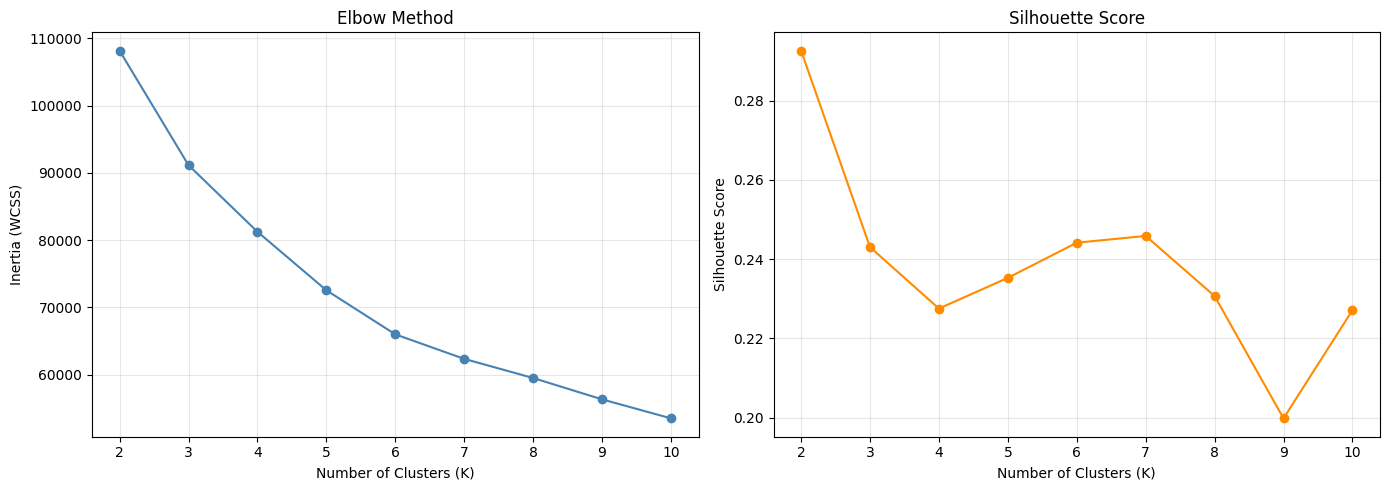

K    Inertia        Silhouette     
-----------------------------------
2    108155.33      0.293          
3    91146.46       0.243          
4    81253.75       0.228          
5    72560.38       0.235          
6    66010.25       0.244          
7    62364.73       0.246          
8    59519.79       0.231          
9    56348.14       0.200          
10   53525.82       0.227          


In [23]:
# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
axes[0].plot(k_range, inertia_scores, marker='o', color='steelblue')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].grid(alpha=0.3)

# Silhouette Score
axes[1].plot(k_range, silhouette_scores, marker='o', color='darkorange')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Print scores in a table for easy reference
print(f"{'K':<5}{'Inertia':<15}{'Silhouette':<15}")
print("-" * 35)
for k, inertia, sil in zip(k_range, inertia_scores, silhouette_scores):
    print(f"{k:<5}{inertia:<15.2f}{sil:<15.3f}")

## K-Means Clustering — Optimal K Selection

**Observation**
Elbow Method shows the largest WCSS drop between K=2 and K=3, followed by gradual decline.
Silhouette Score peaks clearly at K=2 (~0.29), significantly higher than any other K.

**Key Insight**
K=2 emerges as the natural structure of the data — confirmed by 4 independent signals:
the hierarchical dendrogram's largest gap, hierarchical silhouette, K-Means elbow,
and K-Means silhouette all point to the same split. This consistency across methods
indicates a genuine binary structure, not an artifact of any single algorithm.

However, this presents the same business limitation discussed earlier:
2 clusters likely splits customers into broad "high-value vs low-value" groups,
which restricts marketing's ability to tailor offers or design cross-sell strategies
at a meaningful granularity.

**Decision**
Use K=2 — the statistically defensible choice supported by all methods.
For marketing application, layer rule-based sub-segmentation on top of these 2 clusters
to recover actionable granularity without imposing artificial cluster boundaries.

In [24]:
# Run K-Means with K=2 (winner across all methods)
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df['kmeans_cluster'] = kmeans.fit_predict(df_pca)
# Show cluster distribution
print("Cluster distribution:")
print(df['kmeans_cluster'].value_counts().sort_index())

Cluster distribution:
kmeans_cluster
0    5330
1    3620
Name: count, dtype: int64


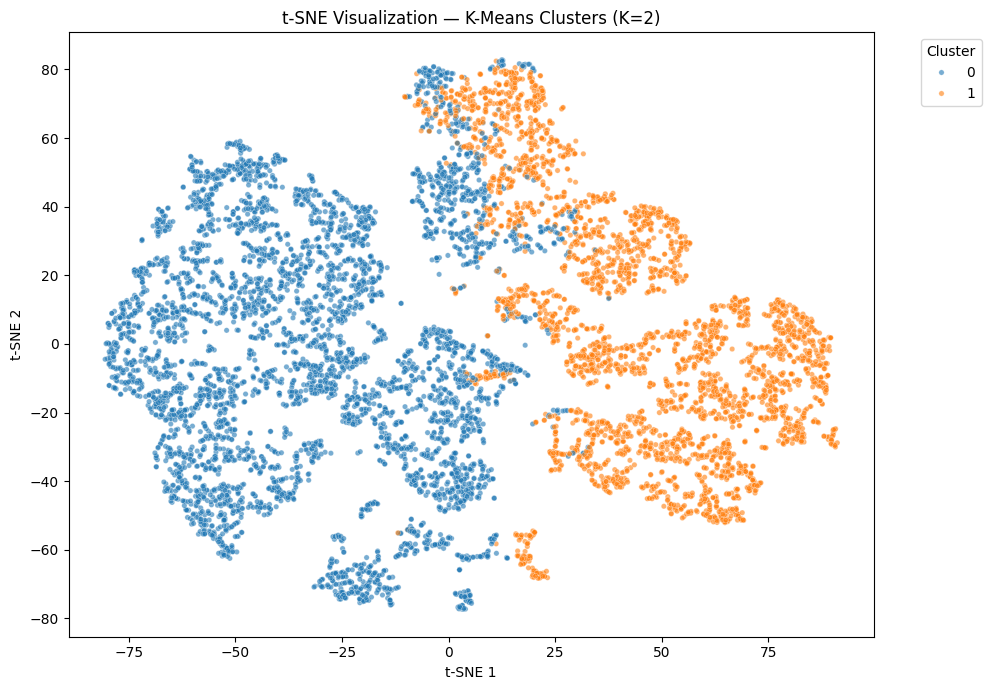

In [25]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=df_tsne[:, 0],
    y=df_tsne[:, 1],
    hue=df['kmeans_cluster'],
    palette='tab10',
    alpha=0.6,
    s=15
)
plt.title('t-SNE Visualization — K-Means Clusters (K=2)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

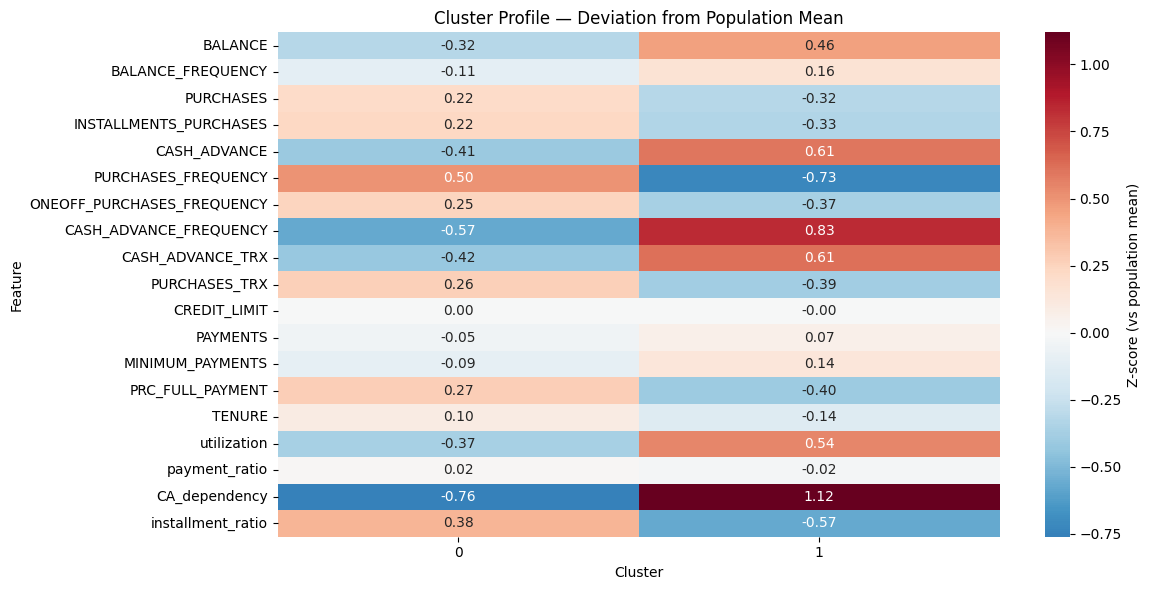

In [26]:
feature_cols = [c for c in df.columns if c not in ['hierarchy_cluster', 'kmeans_cluster']]


cluster_profile = df.groupby('kmeans_cluster')[feature_cols].mean()


overall_mean = df[feature_cols].mean()
overall_std = df[feature_cols].std()
cluster_normalized = (cluster_profile - overall_mean) / overall_std

plt.figure(figsize=(12, 6))
sns.heatmap(
    cluster_normalized.T,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f',
    cbar_kws={'label': 'Z-score (vs population mean)'}
)
plt.title('Cluster Profile — Deviation from Population Mean')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Key Insight — Cluster Personas**

**Cluster 0 — Purchase-Focused Spenders**
Above average in purchase frequency (+0.50), installment ratio (+0.38),
and full payment rate (+0.27). Below average in cash advance dependency (-0.76)
and utilization (-0.37). Customers who use the card for shopping and pay responsibly.

**Cluster 1 — Cash-Reliant Borrowers**
Sharply above average in cash advance dependency (+1.12), cash advance frequency (+0.83),
and utilization (+0.54). Below average in purchase frequency (-0.73) and full payment rate (-0.40).
Customers who use the card mainly for cash withdrawals and carry balance.

**Conclusion**
The K=2 split reflects behavioral patterns (shopping vs cash withdrawal), not wealth tiers.
Both segments share similar credit limits and payment volumes, making the segmentation
genuinely actionable for marketing — distinct strategies can be designed per behavior
without conflating with income level.

In [27]:
cluster_labels_h2 = fcluster(linkage_matrix, t=2, criterion='maxclust') -1 #hierarchy start segment with 1 not 0 as k-mean
df['hierarchy_cluster'] = cluster_labels_h2

# Compare with K-Means
comparison = pd.crosstab(
    df['kmeans_cluster'],
    df['hierarchy_cluster'],
    margins=True
)
print("Agreement between K-Means and Hierarchical:")
print(comparison)

Agreement between K-Means and Hierarchical:
hierarchy_cluster     0     1   All
kmeans_cluster                     
0                  4550   780  5330
1                    53  3567  3620
All                4603  4347  8950


**Observation**
Both algorithms were applied to the same PCA-reduced data with K=2.
A cross-tabulation of cluster assignments shows 8,117 out of 8,950 customers (90.7%)
fall into the same behavioral group in both methods.

**Key Insight**
The 90.7% agreement provides strong cross-algorithm validation — two fundamentally
different clustering approaches independently identified the same binary structure
in customer behavior (Purchase-Focused vs Cash-Reliant).

In [28]:
# Test K=2 to K=6 for hierarchical
for k in [2, 3, 4, 5, 6]:
    labels = fcluster(linkage_matrix, t=k, criterion='maxclust')
    score = silhouette_score(df_pca, labels)
    print(f"K={k}: Silhouette = {score:.3f}")

K=2: Silhouette = 0.260
K=3: Silhouette = 0.212
K=4: Silhouette = 0.189
K=5: Silhouette = 0.185
K=6: Silhouette = 0.194


**Observation**
K=2 produces the highest score (0.260), consistent with the K-Means result (0.290).
All other K values remain below 0.25, indicating weak cluster structure beyond K=2.

**Key Insight**
Hierarchical and K-Means both identify K=2 as the optimal cluster count, providing
strong cross-algorithm validation. While the absolute score (0.260) is modest —
reflecting the continuous nature of customer behavior — it stands clearly above all
other tested K values, marking K=2 as the strongest natural break in the data.

**Decision**
Confirm K=2 as the final cluster count for hierarchical clustering, aligning with
K-Means and the dendrogram's largest top-level gap.

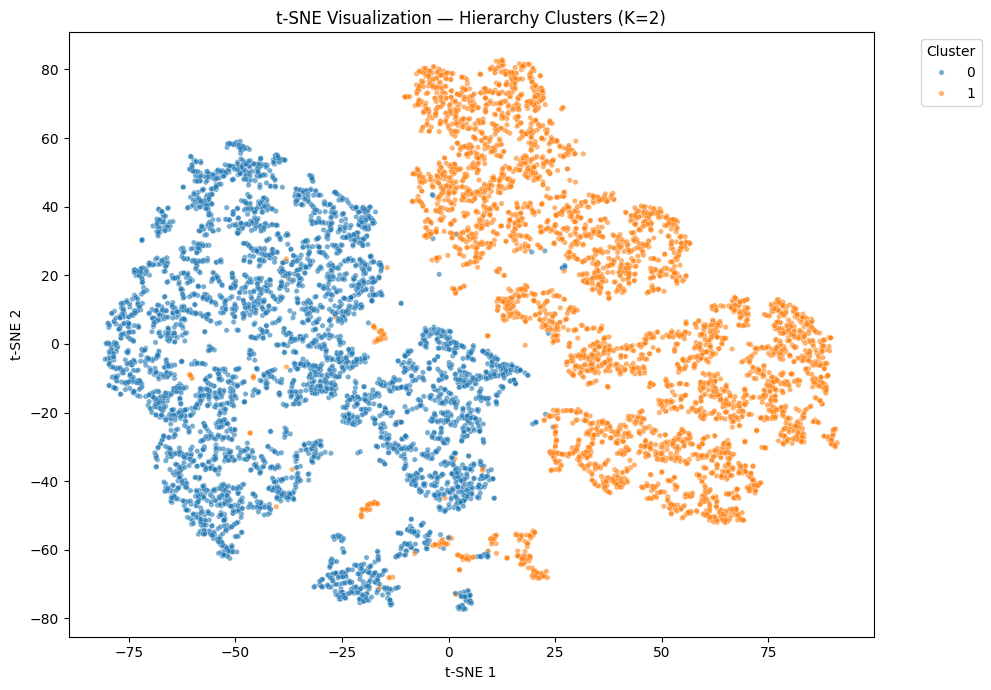

In [29]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=df_tsne[:, 0],
    y=df_tsne[:, 1],
    hue=df['hierarchy_cluster'],
    palette='tab10',
    alpha=0.6,
    s=15
)
plt.title('t-SNE Visualization — Hierarchy Clusters (K=2)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

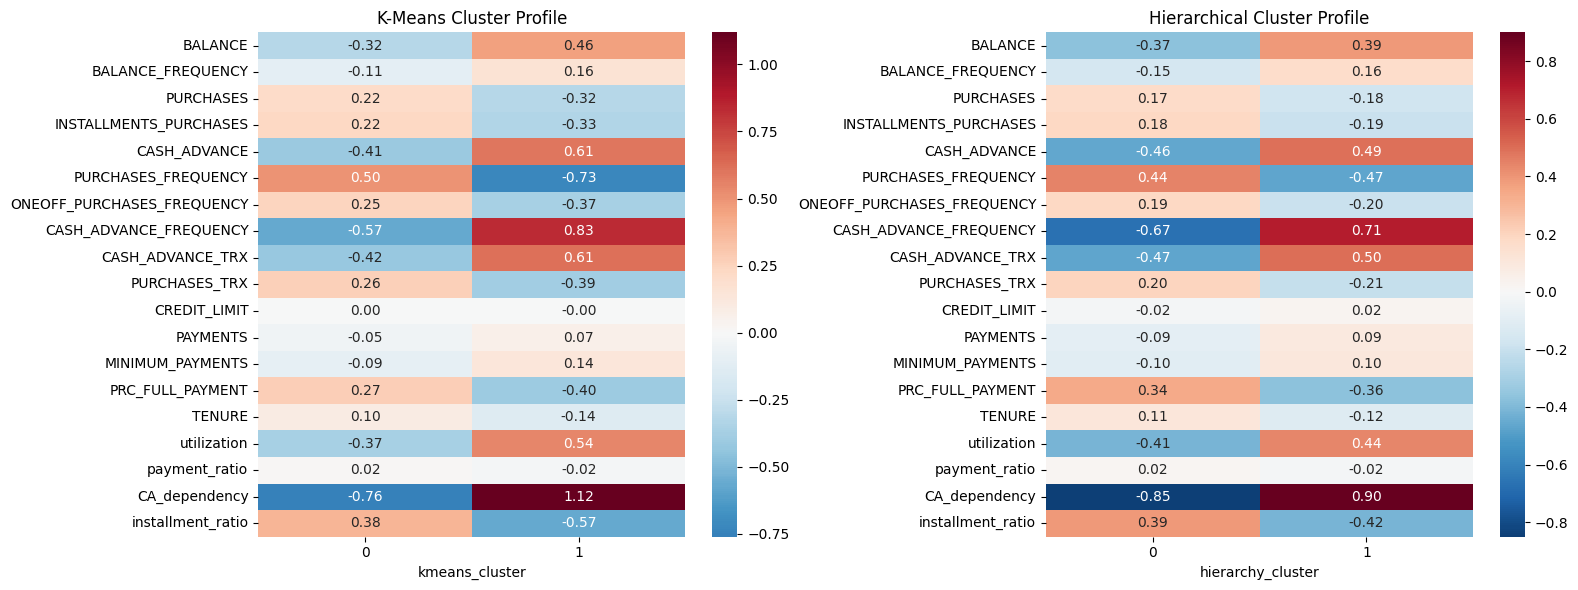

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means heatmap
km_profile = df.groupby('kmeans_cluster')[feature_cols].mean()
km_normalized = (km_profile - overall_mean) / overall_std
sns.heatmap(km_normalized.T, ax=axes[0], cmap='RdBu_r', center=0, annot=True, fmt='.2f')
axes[0].set_title('K-Means Cluster Profile')

# Hierarchical heatmap
hr_profile = df.groupby('hierarchy_cluster')[feature_cols].mean()
hr_normalized = (hr_profile - overall_mean) / overall_std
sns.heatmap(hr_normalized.T, ax=axes[1], cmap='RdBu_r', center=0, annot=True, fmt='.2f')
axes[1].set_title('Hierarchical Cluster Profile')

plt.tight_layout()
plt.show()

## K-Means vs Hierarchical — Heatmap Comparison

**Observation**
Both heatmaps show the same direction (red/blue) across all features — every feature
that is high in one method's Cluster 0 is also high in the other method's Cluster 0,
and vice versa. The magnitudes differ slightly, with K-Means showing more polarized
extremes (e.g. CA_dependency: K-Means +1.12 vs Hierarchical +0.90).

**Key Insight**
The side-by-side view visually confirms the 90.7% agreement seen in the cross-tabulation.
Both algorithms independently identify the same behavioral split — purchase-oriented
versus cash-reliant customers — with the binary structure holding across two
fundamentally different clustering approaches.

The slight magnitude difference reflects how each method assigns borderline customers:
K-Means pushes them toward the nearest centroid (producing sharper extremes),
while Hierarchical merges them via the agglomerative tree (producing softer profiles).


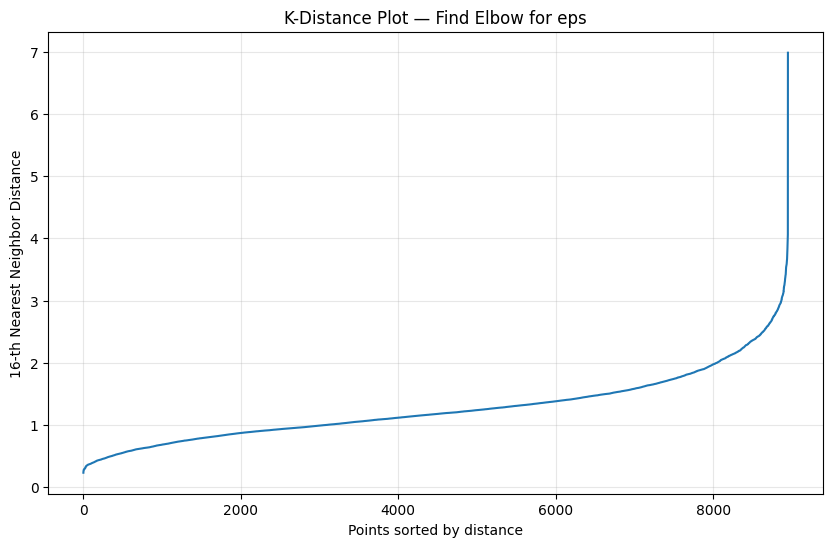

In [31]:
from sklearn.neighbors import NearestNeighbors


# Rule of thumb: min_samples ≈ 2 × n_features
n_features = df_pca.shape[1]
min_samples = 2 * n_features    # = 16

# Calculate distance to k-th nearest neighbor for each point
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(df_pca)
distances, _ = neighbors.kneighbors(df_pca)

# Sort and plot the k-th distance — look for the elbow
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{min_samples}-th Nearest Neighbor Distance')
plt.title('K-Distance Plot — Find Elbow for eps')
plt.grid(alpha=0.3)
plt.show()

In [32]:
from sklearn.cluster import DBSCAN

eps_value = 2  # ← จากกราฟ k-distance

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
df['dbscan_cluster'] = dbscan.fit_predict(df_pca)

# Check results
print("Cluster distribution:")
print(df['dbscan_cluster'].value_counts().sort_index())

# Noise = label -1
noise_count = (df['dbscan_cluster'] == -1).sum()
print(f"\nNoise points: {noise_count} ({noise_count/len(df)*100:.1f}%)")
print(f"Number of clusters (excluding noise): {df['dbscan_cluster'].nunique() - 1}")

Cluster distribution:
dbscan_cluster
-1     295
 0    8641
 1      14
Name: count, dtype: int64

Noise points: 295 (3.3%)
Number of clusters (excluding noise): 2


**Key Insight**
The fact that DBSCAN merges 96.5% of customers into a single dense cluster confirms that
customer behavior forms a continuous spectrum rather than naturally separated groups.
This finding explains why Silhouette scores in K-Means and Hierarchical clustering were
similar across all K values — there is no strong secondary structure beyond the primary
behavioral axis (Purchase vs Cash-Reliant), so any K beyond 2 imposes arbitrary cuts
on a continuous gradient.

**Decision**
Use DBSCAN as a complementary tool for outlier detection rather than primary segmentation.
The 309 customers in noise + micro-cluster represent unusual behavior worth investigating
separately, while K-Means K=2 remains the practical choice for main marketing segmentation.

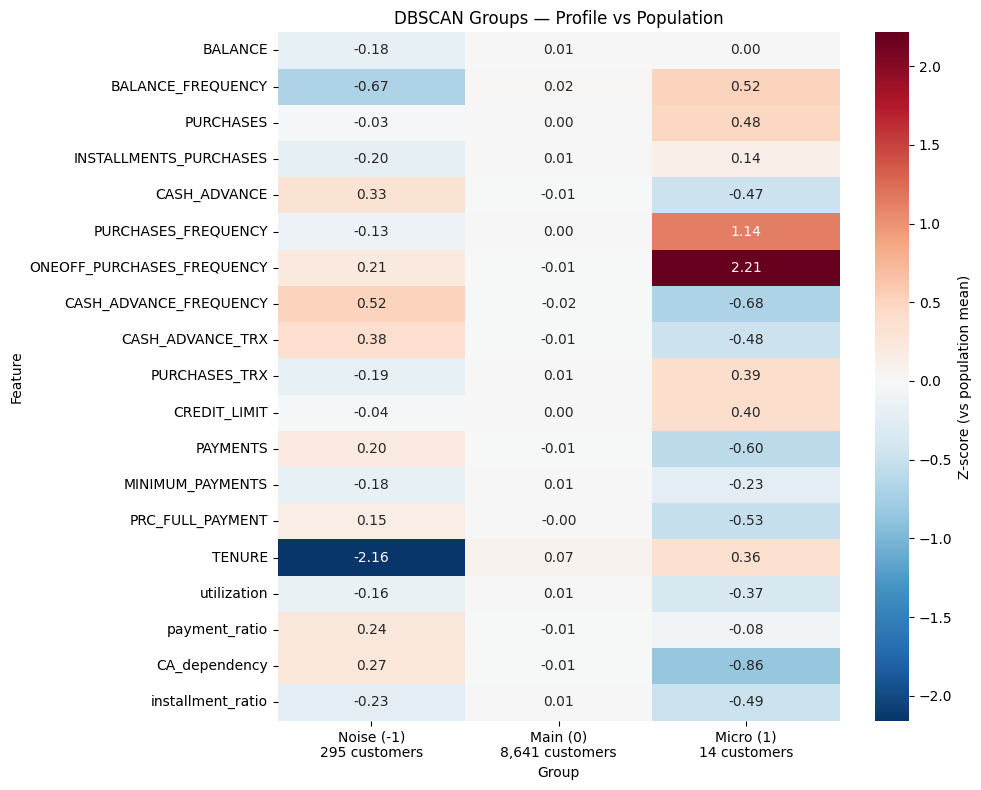

In [33]:
# Exclude cluster columns from features
feature_cols = [c for c in df.columns if c not in ['hierarchy_cluster', 'kmeans_cluster', 'dbscan_cluster']]

# Calculate mean per DBSCAN group
dbscan_profile = df.groupby('dbscan_cluster')[feature_cols].mean()

# Standardize against overall population mean and std
overall_mean = df[feature_cols].mean()
overall_std = df[feature_cols].std()
dbscan_normalized = (dbscan_profile - overall_mean) / overall_std

# Rename index for clarity (groupby sorts keys: -1, 0, 1)
dbscan_normalized.index = ['Noise (-1)\n295 customers',
                            'Main (0)\n8,641 customers',
                            'Micro (1)\n14 customers']

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    dbscan_normalized.T,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f',
    cbar_kws={'label': 'Z-score (vs population mean)'}
)
plt.title('DBSCAN Groups — Profile vs Population')
plt.xlabel('Group')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Observation**
The Main cluster (96.5%) sits at the population average across all features (z-scores ≈ 0),
which is expected since it dominates the dataset. The two anomalous groups reveal
distinctly different patterns from the main population.

**Key Insight — Group Personas**

**Noise (-1) — 295 customers ("Newcomers")**
Defining feature: TENURE (-2.16) — substantially shorter than any other group, marking these
as the newest customers. They show slightly elevated cash advance activity (+0.33 to +0.52)
and below-average balance frequency (-0.67). Likely early-stage users still establishing
their behavioral patterns rather than a coherent behavioral segment.

**Micro (1) — 14 customers ("Hyper-Active Shoppers")**
Defining feature: ONEOFF_PURCHASES_FREQUENCY (+2.21) and PURCHASES_FREQUENCY (+1.14) — both
sharply elevated. They have higher credit limit (+0.40) but lower full-payment rate (-0.53)
and minimal cash advance usage (-0.86). Extreme one-off shoppers who buy frequently and
carry balance — niche high-engagement segment worth case-by-case attention.

In [34]:
import joblib

# Save the K-Means model for production use
joblib.dump(kmeans, 'kmeans_segmentation_model.pkl')
joblib.dump(pca, 'pca_transformer.pkl')
joblib.dump(scaler, 'scaler.pkl')

# To reload later:
# kmeans_loaded = joblib.load('kmeans_segmentation_model.pkl')

['scaler.pkl']

## Final Segmentation Strategy

**Primary Segmentation (K-Means K=2)**

| Segment | Size | Behavioral Hypothesis |
|---|---|---|
| Cluster 0 — Purchase-Focused | 5,330 (60%) | High purchase frequency, low cash advance |
| Cluster 1 — Cash-Reliant | 3,620 (40%) | High cash advance dependency, low purchase activity |

**Outlier Segments (DBSCAN)**

| Group | Size | Notable Pattern |
|---|---|---|
| Noise (-1) | 295 (3.3%) | Newest customers (TENURE -2.16) |
| Micro (1) | 14 (0.2%) | Hyper-active one-off shoppers |

**Suggested Next Steps (Pending Domain Validation)**
1. Validate behavioral hypotheses with banking domain experts
2. Design A/B test for differentiated marketing per segment
3. Investigate the 14-customer micro-cluster as a case study
4. Build onboarding strategy for the 295 newcomer outliers

## Limitations & Future Work

**Limitations**
- Customer behavior shows weak intrinsic dimensionality (single primary axis),
  resulting in low absolute Silhouette scores (~0.26–0.29) across all methods
- Domain expertise required to translate behavioral patterns into business strategies
- Static snapshot — does not capture behavioral changes over time

**Future Work**
- Validate segments against business KPIs (CLV, churn, profitability)
- Time-series analysis to track segment transitions
- Test alternative algorithms (GMM, Spectral Clustering)
- Build a predictive model for segment assignment of new customers